# Notebook 3: HITS Algorithm — Hub & Authority Analysis

The HITS (Hyperlink-Induced Topic Search) algorithm scores nodes in a bipartite
graph. Federal agencies are treated as **hubs** (they point to contractors) and
contractors are treated as **authorities** (they receive contracts from agencies).

A contractor's authority score reflects not just total dollars received, but
structural importance (how many influential agencies contract with them).
An agency's hub score reflects how many high-authority contractors it works with.

**Input:** `contracts_resolved.csv`  
**Output:** `contracts_with_hits.csv`, `corporate_family_authority_scores.csv`

In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [11]:
df = pd.read_csv('contracts_resolved.csv', dtype={'naics_code': str})

print(f"Shape: {df.shape}")
print(f"Unique contractors: {df['recipient_name'].nunique():,}")
print(f"Unique agencies: {df['awarding_agency_name'].nunique():,}")

# Build directed bipartite graph
# Edge direction: agency -> contractor (hub points to authority)
G = nx.DiGraph()

for _, row in df.iterrows():
    agency = row['awarding_agency_name']
    contractor = row['recipient_name']
    
    if G.has_edge(agency, contractor):
        # Accumulate total obligations on existing edge
        G[agency][contractor]['weight'] += row['total_obligated_amount']
    else:
        G.add_edge(agency, contractor, weight=row['total_obligated_amount'])

print(f"\nGraph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Shape: (73350, 7)
Unique contractors: 24,607
Unique agencies: 55

Graph nodes: 24,662
Graph edges: 31,156


In [12]:
# Run HITS algorithm
# max_iter=100 is well beyond typical convergence for this size graph
hits_hubs, hits_authorities = nx.hits(G, max_iter=100, normalized=True)

# Convert to dataframes
hub_df = pd.DataFrame.from_dict(hits_hubs, orient='index', columns=['hub_score'])
auth_df = pd.DataFrame.from_dict(hits_authorities, orient='index', columns=['authority_score'])

# Separate agencies and contractors
# Agencies only appear as sources (hubs), contractors as targets (authorities)
agencies = df['awarding_agency_name'].unique()
contractors = df['recipient_name'].unique()

agency_scores = hub_df[hub_df.index.isin(agencies)].sort_values('hub_score', ascending=False)
contractor_scores = auth_df[auth_df.index.isin(contractors)].sort_values('authority_score', ascending=False)

print("=== Top 15 Hub Agencies ===")
print(agency_scores.head(15))

print("\n=== Top 15 Authority Contractors ===")
print(contractor_scores.head(15))

=== Top 15 Hub Agencies ===
                                               hub_score
Department of Defense                           0.959105
National Aeronautics and Space Administration   0.037524
Department of Energy                            0.001379
Department of Commerce                          0.000750
Department of Homeland Security                 0.000585
Department of Transportation                    0.000382
Department of State                             0.000071
General Services Administration                 0.000068
National Science Foundation                     0.000033
Department of the Interior                      0.000031
Agency for International Development            0.000021
Department of Health and Human Services         0.000015
Department of Education                         0.000010
Department of Justice                           0.000009
Department of Housing and Urban Development     0.000004

=== Top 15 Authority Contractors ===
                      

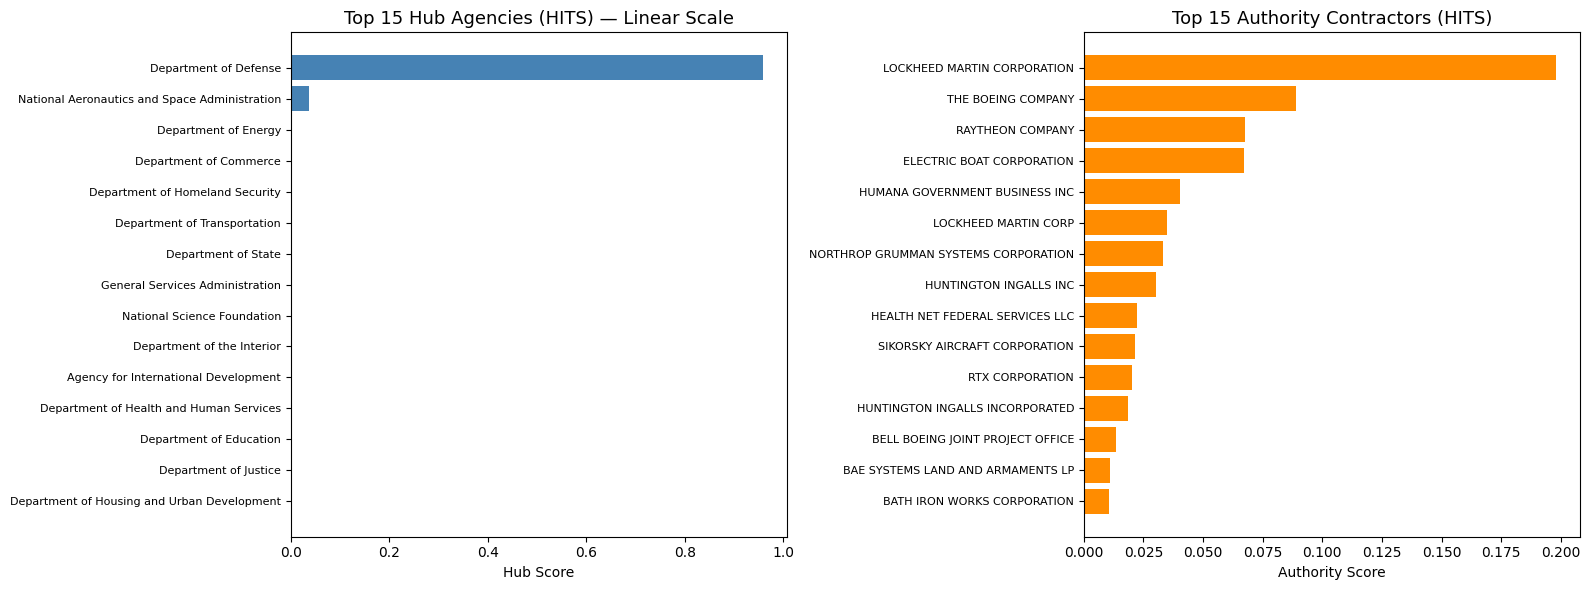

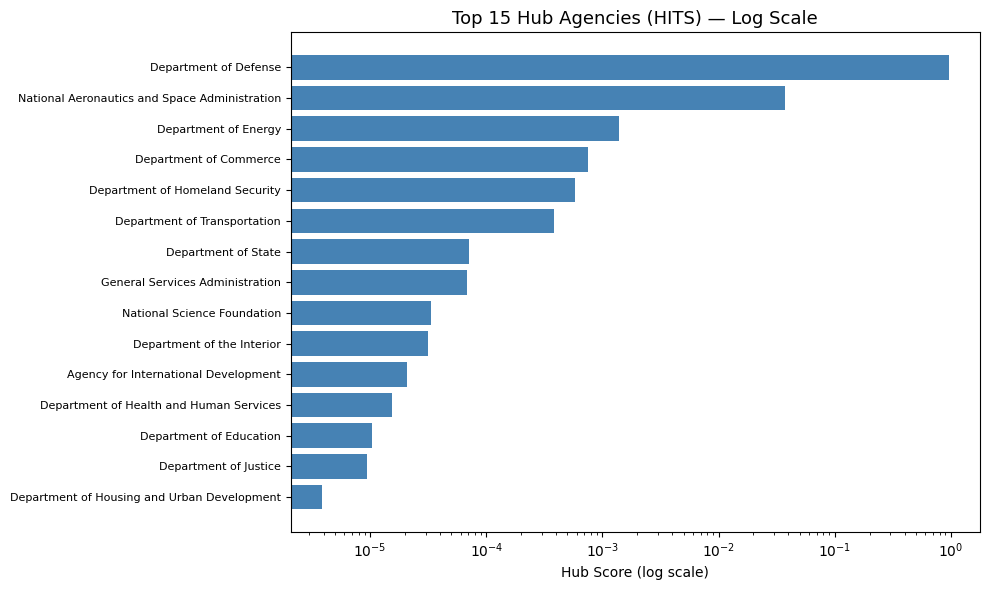

Saved hits_scores.png and hits_scores_log.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 agencies by hub score - linear scale
top_agencies = agency_scores.head(15)
axes[0].barh(top_agencies.index[::-1], top_agencies['hub_score'][::-1], color='steelblue')
axes[0].set_title('Top 15 Hub Agencies (HITS) — Linear Scale', fontsize=13)
axes[0].set_xlabel('Hub Score')
axes[0].tick_params(axis='y', labelsize=8)

# Top 15 contractors by authority score
top_contractors = contractor_scores.head(15)
axes[1].barh(top_contractors.index[::-1], top_contractors['authority_score'][::-1], color='darkorange')
axes[1].set_title('Top 15 Authority Contractors (HITS)', fontsize=13)
axes[1].set_xlabel('Authority Score')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('hits_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Log scale view for agencies — reveals score differences obscured by DoD dominance
fig2, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_agencies.index[::-1], top_agencies['hub_score'][::-1], color='steelblue')
ax.set_xscale('log')
ax.set_title('Top 15 Hub Agencies (HITS) — Log Scale', fontsize=13)
ax.set_xlabel('Hub Score (log scale)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('hits_scores_log.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved hits_scores.png and hits_scores_log.png")

In [14]:
# Merge authority scores back onto main dataframe for use in clustering
contractor_scores_reset = contractor_scores.reset_index()
contractor_scores_reset.columns = ['recipient_name', 'authority_score']

df = df.merge(contractor_scores_reset, on='recipient_name', how='left')

print(f"Null authority scores: {df['authority_score'].isna().sum()}")
print(f"Shape after merge: {df.shape}")

df.to_csv('contracts_with_hits.csv', index=False)
print("Saved contracts_with_hits.csv")

Null authority scores: 0
Shape after merge: (73350, 8)
Saved contracts_with_hits.csv


In [15]:
# Supplementary: Corporate family authority scores
# Aggregate by first two words of contractor name to approximate parent company
def first_two_words(name):
    tokens = name.split()
    return ' '.join(tokens[:2]) if len(tokens) >= 2 else name

contractor_scores_reset['corporate_family'] = contractor_scores_reset['recipient_name'].apply(first_two_words)

family_scores = (
    contractor_scores_reset
    .groupby('corporate_family')['authority_score']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("=== Top 20 Corporate Families by Aggregated Authority Score ===")
print(family_scores.head(20).to_string(index=False))
print(f"\nUnique corporate families: {family_scores['corporate_family'].nunique():,}")
family_scores.to_csv('corporate_family_authority_scores.csv', index=False)
print("\nSaved corporate_family_authority_scores.csv")

=== Top 20 Corporate Families by Aggregated Authority Score ===
     corporate_family  authority_score
      LOCKHEED MARTIN         0.234061
           THE BOEING         0.088836
     RAYTHEON COMPANY         0.067538
        ELECTRIC BOAT         0.067199
   HUNTINGTON INGALLS         0.048944
    HUMANA GOVERNMENT         0.040344
     NORTHROP GRUMMAN         0.040116
           HEALTH NET         0.022279
    SIKORSKY AIRCRAFT         0.021370
      RTX CORPORATION         0.020259
          BAE SYSTEMS         0.018975
          BELL BOEING         0.013400
            BATH IRON         0.010489
        BECHTEL PLANT         0.009566
        UNITED LAUNCH         0.008607
     GENERAL DYNAMICS         0.007896
         FLUOR MARINE         0.007039
UNITEDHEALTH MILITARY         0.006826
           AUSTAL USA         0.006148
      GENERAL ATOMICS         0.006062

Unique corporate families: 23,038

Saved corporate_family_authority_scores.csv
